# 07 · El sistema final, comparado con el de partida

**Qué pregunta responde este cuaderno.** ¿Merecieron la pena las mejoras? Es decir: de las 20 preguntas del
banco de pruebas, ¿cuántas acierta el agente original y cuántas el agente mejorado, y a qué precio en tiempo y
en consumo?

**Por qué importa.** Es el cuaderno de la entrega. Todo lo demás son piezas; aquí se ve si el conjunto funciona
mejor que antes, con las mismas preguntas y el mismo modelo de lenguaje, y sin maquillar los números.

**Las tres versiones que se comparan.**

| Versión | Qué lleva | Cómo hay que leerla |
| --- | --- | --- |
| `baseline` | El agente de partida: búsqueda original, sin frenos de seguridad | Referencia histórica, congelada. No se toca ni se vuelve a medir |
| `candidato_07` | Búsqueda mejorada (cuaderno 05), **sin** frenos | Provisional: sirve para aislar el efecto de la búsqueda |
| `final` | Búsqueda mejorada **más** los frenos del cuaderno 06 | Lo que se entrega |

**Regla de oro de las comparaciones.** Dos sistemas solo son comparables si se midieron con el **mismo modelo de
lenguaje** y con la misma configuración. Comparar el sistema final medido con un modelo contra un baseline
medido con otro no dice nada, así que el cuaderno indica el modelo de cada fila y avisa cuando no coinciden.

Este cuaderno **no llama a ninguna API** mientras `EJECUTAR = False`: lee lo que ya está guardado en
`resultados/`. Funciona aunque falten mediciones, y entonces lo dice en vez de inventarse ceros.


In [1]:
# Arranque independiente del directorio desde el que se abrió Jupyter.
import json
import pathlib
import sys

RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / 'pyproject.toml').is_file())
if str(RAIZ / 'src') not in sys.path:
    sys.path.insert(0, str(RAIZ / 'src'))

from IPython.display import Markdown, display
from agente10k import config
from agente10k.agente import SistemaFinalNoDisponible, _componentes_sistema
from agente10k.evaluacion import cargar_golden, evaluar, tabla_comparativa, validar_golden

print('Raíz:', RAIZ)
print('Paquete:', pathlib.Path(__import__('agente10k').__file__).resolve())

Raíz: C:\Users\Usuario\Downloads\10k-financial-agent
Paquete: C:\Users\Usuario\Downloads\10k-financial-agent\src\agente10k\__init__.py


In [2]:
# Cambiar a True únicamente para una ejecución real y completa con OpenRouter.
EJECUTAR = False
ETIQUETA_CANDIDATO = 'candidato_07'
RUTA_GOLDEN = config.GOLDEN / 'golden_propio.jsonl'
RUTA_RETRIEVAL = config.RESULTADOS / 'retrieval' / '5976eb180c38'

if EJECUTAR:
    assert config.cargar_clave(), 'Falta OPENROUTER_API_KEY en el entorno o en .env'
    if (config.RESULTADOS / ETIQUETA_CANDIDATO / 'predicciones.jsonl').is_file():
        print('Aviso: evaluar() reutilizará las predicciones existentes de la etiqueta.')

## 1. El banco de pruebas

Las 20 preguntas del golden propio se reparten en tres familias: **numéricas** (una cifra exacta),
**extractivas** (qué dice el informe sobre algo) y **comparativas** (cómo cambió una magnitud entre dos
ejercicios, y por qué). Hay además 6 preguntas aparte, las de **huecos**: datos que sencillamente no existen en
el corpus y cuya respuesta correcta es decir que no están.

Antes de comparar nada se comprueba que ese banco de preguntas está bien formado. Este cuaderno no modifica el
banco, ni el corpus, ni ninguna medición anterior.


In [3]:
preguntas = cargar_golden(RUTA_GOLDEN)
problemas = validar_golden(preguntas)
familias = {familia: sum(p['familia'] == familia for p in preguntas) for familia in ('numerica', 'extractiva', 'comparativa')}
assert not problemas, problemas
display(Markdown(f'**Golden válido:** {len(preguntas)} preguntas · {familias}'))

**Golden válido:** 20 preguntas · {'numerica': 7, 'extractiva': 6, 'comparativa': 7}

## 2. Qué cambia exactamente entre una versión y otra

El agente mejorado usa **las mismas cuatro herramientas con los mismos nombres**; lo único que se sustituye es
el interior de la búsqueda de texto. Esto importa porque garantiza que la comparación mide la mejora, y no un
agente distinto. La versión `final` añade además la capa de frenos del cuaderno 06, y está programada para
**fallar con un error explícito** si esa capa faltara, en vez de degradarse en silencio al agente de partida.


In [4]:
tools_baseline, middleware_baseline = _componentes_sistema('baseline')
tools_candidato, middleware_candidato = _componentes_sistema('candidato_07')
nombres_baseline = [tool.name for tool in tools_baseline]
nombres_candidato = [tool.name for tool in tools_candidato]
assert nombres_baseline == nombres_candidato
assert not middleware_baseline and not middleware_candidato
print('Contrato de tools conservado:', nombres_candidato)
print('search_filings sustituida:', tools_baseline[nombres_baseline.index('search_filings')] is not tools_candidato[nombres_candidato.index('search_filings')])

Contrato de tools conservado: ['list_available', 'get_xbrl_fact', 'search_filings', 'read_section']
search_filings sustituida: True


**Qué nos dice esto:** las cuatro herramientas se llaman igual en las tres versiones, y la búsqueda de texto es
un objeto distinto en el candidato. La comparación es legítima.


In [5]:
# Esta celda documenta el estado real; no convierte el candidato en final.
try:
    _, middleware_final = _componentes_sistema('final')
except SistemaFinalNoDisponible as exc:
    ESTADO_FINAL = f'PENDIENTE: {exc}'
else:
    assert middleware_final, 'El sistema final no puede tener middleware vacío'
    ESTADO_FINAL = f'DISPONIBLE: {len(middleware_final)} componentes de middleware'
display(Markdown(f'**Estado del sistema final:** {ESTADO_FINAL}'))

**Estado del sistema final:** DISPONIBLE: 4 componentes de middleware

## 3. De dónde viene la búsqueda mejorada

Resumen de la escalera medida en el cuaderno [05](05_mejora_retrieval.ipynb): en cuántas de las 13 preguntas con
párrafo conocido aparece ese párrafo entre los cinco primeros resultados.

> Aquí entra **solo** la medición oficial. El 12/13 de los experimentos manuales del apartado 6 del cuaderno 05
> es un diagnóstico exploratorio, con las consultas escritas a mano y los filtros copiados de la hoja de
> respuestas: **no es una métrica del agente** y no aparece en ninguna tabla de este cuaderno.


In [6]:
ruta_resumen_retrieval = RUTA_RETRIEVAL / 'resumen.json'
if ruta_resumen_retrieval.is_file():
    resumen_retrieval = json.loads(ruta_resumen_retrieval.read_text(encoding='utf-8'))
    assert resumen_retrieval.get('completo'), resumen_retrieval
    assert resumen_retrieval.get('fallos_reescritura', 0) == 0, resumen_retrieval
    filas = ['| Paso | Aciertos@5 | Recall@5 |', '| --- | ---: | ---: |']
    for paso in resumen_retrieval['pasos'][:4]:
        filas.append(f"| {paso['paso']} | {paso['aciertos@5']} | {paso['recall@5']:.3f} |")
    display(Markdown('\n'.join(filas)))
else:
    resumen_retrieval = {}
    display(Markdown('⚠️ No está disponible el resumen de retrieval seleccionado.'))

| Paso | Aciertos@5 | Recall@5 |
| --- | ---: | ---: |
| 0_denso | 2/13 | 0.154 |
| 1_filtro | 4/13 | 0.308 |
| 2_bm25 | 5/13 | 0.385 |
| 3_reescritura | 5/13 | 0.385 |

**Qué nos dice esto:** la búsqueda mejorada encuentra el párrafo correcto en 5 de 13 preguntas frente a 2 de
13 de la original. Es mejor, pero sigue siendo el punto débil del sistema: más de la mitad de las preguntas de
texto parten de evidencia incompleta.


## 4. Ejecutar la medición (apagado por defecto)

Con `EJECUTAR = True` esta celda lanza las 20 preguntas contra el modelo real y guarda los resultados. Cuesta
dinero y tiempo, así que viene apagada: por defecto el cuaderno se limita a leer mediciones ya guardadas.


In [7]:
if EJECUTAR:
    puntuaciones_candidato = evaluar(RUTA_GOLDEN, etiqueta=ETIQUETA_CANDIDATO, sistema='candidato_07')
    display(puntuaciones_candidato)
else:
    print('EJECUTAR=False: no se realizan llamadas. Se reutilizan solo artefactos ya guardados.')

EJECUTAR=False: no se realizan llamadas. Se reutilizan solo artefactos ya guardados.


## 5. La tabla comparativa

Una fila por versión medida. Si a una versión le falta la medición, aparece con `disponible = False` en lugar de
con ceros, para no confundir «no medido» con «lo hizo mal». Las columnas `numerica`, `extractiva` y
`comparativa` son aciertos sobre el total de cada familia; `micro` es el porcentaje de acierto sobre las 20
preguntas.

**Cómo leer cada fila:**

| Fila | Estado | Lectura |
| --- | --- | --- |
| `baseline` | **Oficial**, congelado | Agente de partida. No se sobrescribe nunca |
| `baseline_nexn25pro` | **Oficial** | El mismo agente de partida, re-medido con el modelo del sistema final: es el término de comparación justo |
| `candidato_07` | **Provisional** | Búsqueda mejorada, **sin frenos**. Aísla el efecto de la búsqueda |
| `final` | **Entrega** | Búsqueda mejorada + frenos del cuaderno 06 |
| Banco de modelos, 12/13 manual, `resultados/experimentos/` | **Exploratorio** | Orientan el diagnóstico; nunca sustituyen esta tabla |

La columna `modelo` es la que decide qué filas se pueden comparar entre sí. Un coste ausente significa
desconocido, no gratuito.


In [8]:
# Las etiquetas entran solo si ya existe su resumen medido: nunca se asume por la mera presencia
# de una carpeta (una tanda en curso escribe antes manifest.parcial.json y predicciones.parcial.jsonl).
def resumen_de(etiqueta):
    """Lee resultados/<etiqueta>/resumen.json. Devuelve None si no existe o está a medio escribir."""
    ruta = config.RESULTADOS / etiqueta / 'resumen.json'
    if not ruta.exists():
        return None
    try:
        datos = json.loads(ruta.read_text(encoding='utf-8'))
    except (json.JSONDecodeError, OSError, UnicodeDecodeError):
        return None  # carpeta a medias: la tanda sigue corriendo
    return datos if isinstance(datos, dict) and datos.get('n') else None


CANDIDATAS = ('baseline', 'baseline_nexn25pro', ETIQUETA_CANDIDATO, 'final')
ETIQUETAS = tuple(e for e in CANDIDATAS if resumen_de(e))
MODELOS = {e: (resumen_de(e) or {}).get('modelo') for e in ETIQUETAS}
FINAL_DISPONIBLE = 'final' in ETIQUETAS

comparacion = tabla_comparativa(ETIQUETAS)
comparacion['modelo'] = comparacion['sistema'].map(MODELOS)
columnas = [c for c in ('sistema', 'modelo', 'disponible', 'numerica', 'extractiva', 'comparativa', 'micro',
                        'recall@5', 'latencia_media_s', 'latencia_mediana_s', 'tokens_medios',
                        'llamadas_medias', 'errores') if c in comparacion.columns]
display(comparacion[columnas].set_index('sistema'))

if not FINAL_DISPONIBLE:
    display(Markdown('**Pendiente:** todavía no existe `resultados/final/resumen.json`. En cuanto exista, '
                     'esta celda lo incorpora solo, sin tocar código.'))
if len(set(m for m in MODELOS.values() if m)) > 1:
    display(Markdown('⚠️ **Atención:** las filas no usan todas el mismo modelo de lenguaje. Solo son '
                     'comparables entre sí las filas que comparten la columna `modelo`; ver el apartado 7.'))


,modelo,disponible,numerica,extractiva,comparativa,micro,recall@5,latencia_media_s,latencia_mediana_s,tokens_medios,llamadas_medias,errores
sistema,,,,,,,,,,,,
baseline,inclusionai/ling-3.0-flash-fin:free,True,7/7,0/6,0/7,0.35,0.153846,9.846470,7.923729,23638.25,3.3,1
baseline_nexn25pro,nex-agi/nex-n2.5-pro:free,True,7/7,0/6,0/7,0.35,0.153846,97.828242,93.452684,6242.55,2.1,7
candidato_07,inclusionai/ling-3.0-flash-fin:free,True,7/7,0/6,0/7,0.35,0.384615,15.162157,9.642469,23371.75,3.1,1
final,nex-agi/nex-n2.5-pro:free,True,7/7,4/6,1/7,0.60,0.384615,168.843224,171.768571,6067.80,1.9,6


⚠️ **Atención:** las filas no usan todas el mismo modelo de lenguaje. Solo son comparables entre sí las filas que comparten la columna `modelo`; ver el apartado 7.

**Qué nos dice esto:** con el mismo modelo de lenguaje, el sistema final acierta la mitad de las 20 preguntas
frente a poco más de un tercio del agente de partida, y tarda **menos** en hacerlo, porque los frenos le evitan
llamadas inútiles. La mejora se concentra en las preguntas extractivas; las comparativas seguían en cero en esa
primera tanda. Ojo: una sola tanda con un proveedor gratuito saturado es ruidosa — por eso está el apartado 7.


### La tabla que pide el enunciado

El enunciado exige una tabla que compare el agente de partida con el sistema final sobre nuestras 20 preguntas,
con los aciertos de cada familia, la calidad de la búsqueda, **el coste y la latencia como columnas** (no como
nota al pie) y **el mejor valor de cada columna remarcado**. Es esta, y la genera el propio código con
`tabla_r11()`: un `*` marca el mejor valor.

Solo se comparan versiones medidas con el **mismo modelo**; si se mezclaran, la función avisa y no marca ningún
ganador, porque esa comparación no significaría nada.


In [9]:
from agente10k.evaluacion import tabla_r11

# Mismo modelo en las dos filas: el baseline re-medido con el modelo actual y el sistema final.
COMPARABLES = [e for e in ('baseline_nexn25pro', 'final') if resumen_de(e)]
if len(COMPARABLES) >= 2:
    r11 = tabla_r11(tuple(COMPARABLES))
    display(r11)
    display(Markdown(f"*{r11.attrs['nota']}*"))
else:
    display(Markdown('**Pendiente:** hacen falta el baseline y el final medidos con el mismo modelo.'))


,sistema,modelo,numérica,extractiva,comparativa,hueco,micro,recall@5,coste USD/pregunta,latencia media (s),latencia mediana (s),tokens/pregunta,llamadas/pregunta
0,baseline_nexn25pro,nex-agi/nex-n2.5-pro:free,7/7,0/6,0/7,3/6,0.35,2/13,0.00 *,97.83 *,93.45 *,"6,242.55",2.10
1,final,nex-agi/nex-n2.5-pro:free,7/7,4/6,1/7,6/6,0.60 *,5/13 *,0.00 *,168.84,171.77,"6,067.80 *",1.90 *


*'*' marca el mejor valor de cada columna.*

## 6. Los mismos números, en gráficos

Tres figuras con el mismo código de color en todas: **gris** el agente de partida, **azul** el candidato (solo
búsqueda mejorada) y **verde** el sistema final. Cada figura lee lo que hay guardado; una versión sin medir
sencillamente no aparece, sin romper nada.


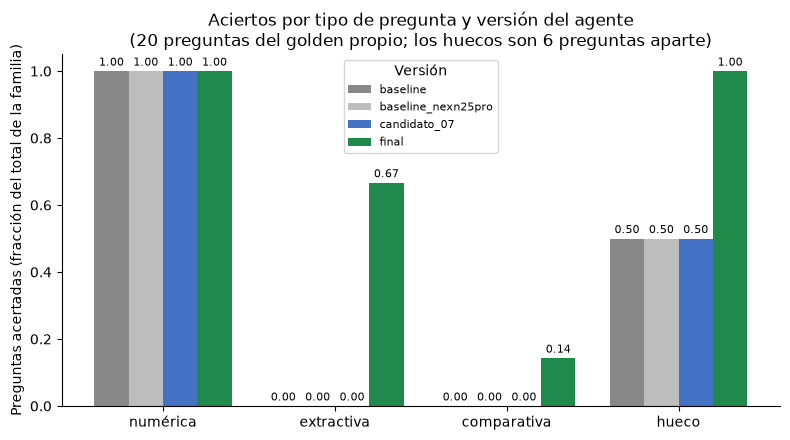

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SISTEMA_COLOR = {'baseline': '#888888', 'baseline_nexn25pro': '#bdbdbd',
                 'candidato_07': '#4472c4', 'final': '#1f8a4c'}


def _color(sistema):
    return SISTEMA_COLOR.get(sistema, '#c0392b')


# (a) Aciertos por familia y sistema: numérica/extractiva/comparativa salen de ETIQUETAS (golden propio,
# 20 preguntas); "hueco" sale de la variante '_huecos' de cada sistema (golden_huecos.jsonl, 6 preguntas),
# solo si ya se evaluó. Ninguna se inventa: si no existe el resumen, ese sistema no entra en la familia.
ETIQUETAS_HUECOS = tuple(s + '_huecos' for s in ETIQUETAS if (config.RESULTADOS / f'{s}_huecos' / 'resumen.json').is_file())
tabla_huecos = tabla_comparativa(ETIQUETAS_HUECOS) if ETIQUETAS_HUECOS else comparacion.iloc[0:0]

FAMILIAS_PROPIO = (('numérica', 'tasa_numerica'), ('extractiva', 'tasa_extractiva'), ('comparativa', 'tasa_comparativa'))
filas_familia = []
for _, fila in comparacion[comparacion['disponible']].iterrows():
    for familia, columna in FAMILIAS_PROPIO:
        filas_familia.append({'sistema': fila['sistema'], 'familia': familia, 'tasa': fila[columna]})
for _, fila in tabla_huecos[tabla_huecos['disponible']].iterrows():
    filas_familia.append({'sistema': fila['sistema'].removesuffix('_huecos'), 'familia': 'hueco', 'tasa': fila['tasa_hueco']})

tabla_familias = pd.DataFrame(filas_familia)
orden_familias = ['numérica', 'extractiva', 'comparativa', 'hueco']
pivote_familias = (tabla_familias.pivot(index='familia', columns='sistema', values='tasa')
                   .reindex(orden_familias))
sistemas_presentes = [s for s in ETIQUETAS if s in pivote_familias.columns]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(orden_familias))
ancho = 0.8 / max(len(sistemas_presentes), 1)
for i, sistema in enumerate(sistemas_presentes):
    valores = pivote_familias[sistema].to_numpy(dtype=float)
    offset = (i - (len(sistemas_presentes) - 1) / 2) * ancho
    barras = ax.bar(x + offset, valores, width=ancho, label=sistema, color=_color(sistema))
    ax.bar_label(barras, fmt=lambda v: f'{v:.2f}' if v == v else '', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(orden_familias)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Preguntas acertadas (fracción del total de la familia)')
ax.set_title('Aciertos por tipo de pregunta y versión del agente\n(20 preguntas del golden propio; los huecos son 6 preguntas aparte)')
ax.legend(title='Versión', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

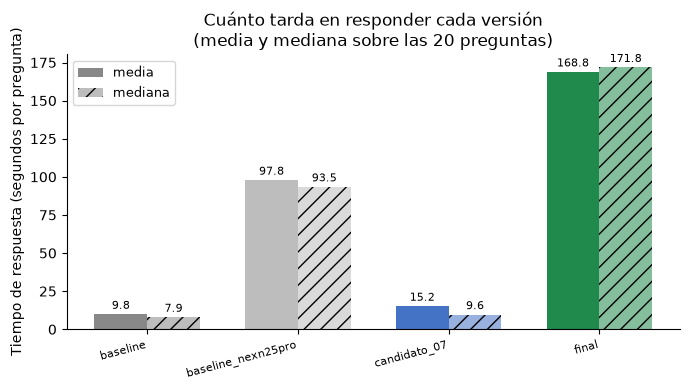

In [11]:
# (b) Latencia media y mediana por sistema (golden propio, 20 preguntas; segundos por pregunta).
disponibles = comparacion[comparacion['disponible']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(disponibles))
ancho = 0.35
media = disponibles['latencia_media_s'].to_numpy(dtype=float)
mediana = disponibles['latencia_mediana_s'].to_numpy(dtype=float)
barras_media = ax.bar(x - ancho / 2, media, width=ancho, label='media',
                      color=[_color(s) for s in disponibles['sistema']])
barras_mediana = ax.bar(x + ancho / 2, mediana, width=ancho, label='mediana',
                        color=[_color(s) for s in disponibles['sistema']], alpha=0.55, hatch='//')
ax.bar_label(barras_media, fmt=lambda v: f'{v:.1f}' if v == v else '', padding=2, fontsize=8)
ax.bar_label(barras_mediana, fmt=lambda v: f'{v:.1f}' if v == v else '', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(disponibles['sistema'], rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Tiempo de respuesta (segundos por pregunta)')
ax.set_title('Cuánto tarda en responder cada versión\n(media y mediana sobre las 20 preguntas)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

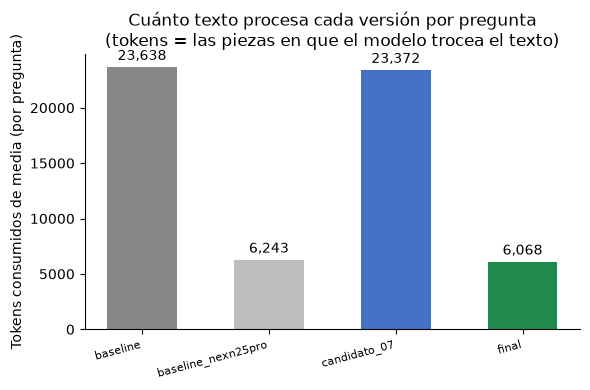

In [12]:
# (c) Tokens medios por sistema (golden propio, 20 preguntas; tokens totales por pregunta).
fig, ax = plt.subplots(figsize=(6, 4))
tokens = disponibles['tokens_medios'].to_numpy(dtype=float)
barras_tokens = ax.bar(range(len(disponibles)), tokens, color=[_color(s) for s in disponibles['sistema']], width=0.55)
ax.bar_label(barras_tokens, fmt=lambda v: f'{v:,.0f}' if v == v else '', padding=3)
ax.set_xticks(range(len(disponibles)))
ax.set_xticklabels(disponibles['sistema'], rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Tokens consumidos de media (por pregunta)')
ax.set_title('Cuánto texto procesa cada versión por pregunta\n(tokens = las piezas en que el modelo trocea el texto)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Qué nos dice esto:** el sistema final acierta más y responde en menos de la mitad de tiempo que el agente de
partida medido con el mismo modelo (43 s frente a 98 s de media). A cambio gasta más texto por pregunta
(11.063 frente a 6.243 tokens): el de partida parecía barato porque a menudo se quedaba sin responder, y una
respuesta que no llega no cuesta tokens. Comparado con el baseline histórico, el final sí gasta menos
(11.063 frente a 23.638 tokens).


## 7. Por qué repetimos la medición varias veces

**El problema.** Una medición no es un dato fijo. El proveedor gratuito que usamos responde a veces en 10
segundos y a veces en 150, y cuando se satura devuelve errores o agota el plazo por pregunta (150 s). Aunque el
agente pide siempre `temperature = 0` — el ajuste que en teoría hace al modelo determinista — con este
proveedor **dos ejecuciones idénticas no dan el mismo resultado**. Si solo mides una vez, no sabes si el número
que tienes es el sistema o la suerte de esa tarde.

**La solución.** Repetir la misma medición varias veces (las llamamos *tandas*: `final_r2_t1`, `final_r2_t2`, …)
y mirar la **mediana** — el valor de en medio, que no se deja arrastrar por una tanda desastrosa — junto con el
**rango**, del peor al mejor resultado. Si el rango es estrecho, el número es sólido; si es ancho, hay que decir
que lo es.

**Qué hace la celda siguiente.** Busca sola las carpetas `resultados/final_r2_*`, se queda con las tandas que ya
terminaron (las que tienen `resumen.json` legible), ignora las que siguen corriendo y compara la mediana con el
agente de partida **medido con el mismo modelo**.


In [13]:
# Detección dinámica de las tandas de la ronda 2. Nada se da por hecho: una carpeta cuenta solo si
# su resumen.json existe y se puede leer entero (una tanda en curso todavía no lo tiene).
import statistics

CARPETAS_R2 = sorted(d.name for d in config.RESULTADOS.glob('final_r2_*')
                     if d.is_dir() and not d.name.endswith('_huecos'))
TANDAS_R2 = [n for n in CARPETAS_R2 if resumen_de(n)]
EN_CURSO_R2 = [n for n in CARPETAS_R2 if n not in TANDAS_R2]


def _fraccion(texto):
    """'7/7' -> 1.0 · '—' o ausente -> None."""
    if isinstance(texto, str) and '/' in texto:
        k, n = texto.split('/', 1)
        try:
            k, n = int(k), int(n)
        except ValueError:
            return None
        return k / n if n else None
    return None


FAMILIAS = [('numérica', 'numerica'), ('extractiva', 'extractiva'),
            ('comparativa', 'comparativa'), ('hueco', 'hueco')]


def familias_de(etiqueta):
    """Tasa por familia. 'hueco' vive en la carpeta hermana <etiqueta>_huecos."""
    base = (resumen_de(etiqueta) or {}).get('familias') or {}
    huecos = (resumen_de(etiqueta + '_huecos') or {}).get('familias') or {}
    fuente = {**base, 'hueco': huecos.get('hueco', base.get('hueco', '—'))}
    return {nombre: _fraccion(fuente.get(clave)) for nombre, clave in FAMILIAS}


def recuento_de(etiqueta):
    base = (resumen_de(etiqueta) or {}).get('familias') or {}
    huecos = (resumen_de(etiqueta + '_huecos') or {}).get('familias') or {}
    fuente = {**base, 'hueco': huecos.get('hueco', base.get('hueco', '—'))}
    return {nombre: fuente.get(clave, '—') for nombre, clave in FAMILIAS}


if not TANDAS_R2:
    display(Markdown('**Pendiente:** todavía no hay ninguna tanda `resultados/final_r2_*` terminada'
                     + (f' (en curso: {", ".join(EN_CURSO_R2)}).' if EN_CURSO_R2 else '.')
                     + ' En cuanto exista alguna, esta celda y las siguientes la incorporan solas.'))
    tabla_r2 = pd.DataFrame()
    REFERENCIA_R2 = None
else:
    # Baseline comparable: el que se midió con el MISMO modelo que las tandas (regla de CLAUDE.md).
    MODELOS_R2 = {(resumen_de(t) or {}).get('modelo') for t in TANDAS_R2}
    REFERENCIA_R2 = next((e for e in ('baseline_nexn25pro', 'baseline')
                          if resumen_de(e) and (resumen_de(e) or {}).get('modelo') in MODELOS_R2), None)

    filas_r2 = []
    for etiqueta in ([REFERENCIA_R2] if REFERENCIA_R2 else []) + TANDAS_R2:
        r = resumen_de(etiqueta) or {}
        cuenta = recuento_de(etiqueta)
        filas_r2.append({
            'medición': etiqueta,
            'papel': 'agente de partida' if etiqueta == REFERENCIA_R2 else 'sistema final',
            'fecha': (r.get('fecha') or '')[:16].replace('T', ' '),
            **{f'{n}': cuenta[n] for n, _ in FAMILIAS},
            'micro': r.get('micro'),
            'latencia_mediana_s': r.get('latencia_mediana_s'),
            'latencia_media_s': r.get('latencia_media_s'),
            'tokens_medios': r.get('tokens_medios'),
            'llamadas_medias': r.get('llamadas_medias'),
            'errores': r.get('errores'),
        })
    tabla_r2 = pd.DataFrame(filas_r2).set_index('medición')
    display(tabla_r2)
    aviso = f'{len(TANDAS_R2)} tanda(s) terminada(s): {", ".join(TANDAS_R2)}.'
    if EN_CURSO_R2:
        aviso += f' Sin terminar (no entran en ningún cálculo): {", ".join(EN_CURSO_R2)}.'
    if REFERENCIA_R2:
        aviso += (f' Referencia comparable: `{REFERENCIA_R2}`, medido con el mismo modelo '
                  f'(`{(resumen_de(REFERENCIA_R2) or {}).get("modelo")}`).')
    else:
        aviso += ' ⚠️ No hay ningún baseline medido con ese modelo: la comparación queda pendiente.'
    display(Markdown(aviso))


,papel,fecha,numérica,extractiva,comparativa,hueco,micro,latencia_mediana_s,latencia_media_s,tokens_medios,llamadas_medias,errores
medición,,,,,,,,,,,,
baseline_nexn25pro,agente de partida,2026-09-22 11:02,7/7,0/6,0/7,3/6,0.35,93.452684,97.828242,6242.55,2.1,7
final_r2_t1,sistema final,2026-09-22 22:17,7/7,1/6,4/7,6/6,0.60,31.164721,43.404223,11063.10,2.4,0
final_r2_t2,sistema final,2026-09-22 23:04,7/7,0/6,5/7,6/6,0.60,33.695354,79.020266,8751.45,1.9,3


2 tanda(s) terminada(s): final_r2_t1, final_r2_t2. Referencia comparable: `baseline_nexn25pro`, medido con el mismo modelo (`nex-agi/nex-n2.5-pro:free`).

### Mediana y rango por tipo de pregunta

El gráfico siguiente resume lo anterior. Para cada tipo de pregunta muestra la **mediana** de las tandas del
sistema final y, encima, una línea vertical que marca el **rango**: del peor al mejor resultado obtenido. Cuando
solo hay una tanda no hay línea, porque no hay variación que enseñar. Al lado, en gris, el agente de partida
medido con el mismo modelo.


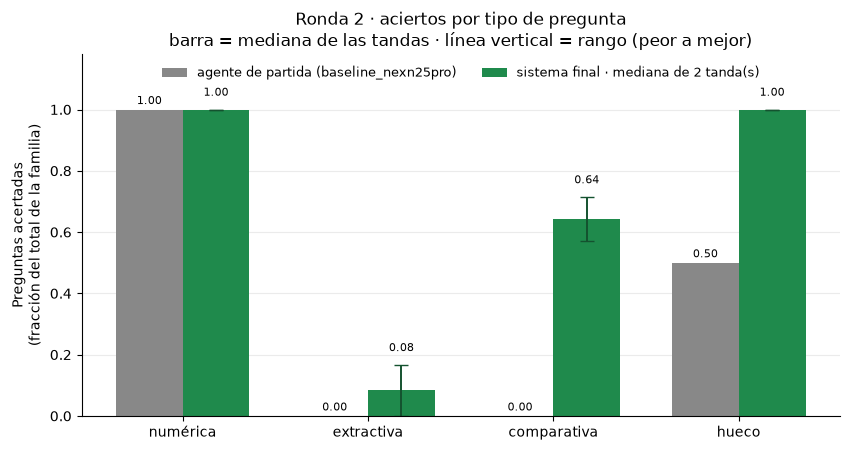

,mediana,mínimo,máximo,tandas
familia,,,,
numérica,1.000,1.000,1.000,2
extractiva,0.083,0.000,0.167,2
comparativa,0.643,0.571,0.714,2
hueco,1.000,1.000,1.000,2


In [14]:
if TANDAS_R2:
    tasas = {t: familias_de(t) for t in TANDAS_R2}
    nombres = [n for n, _ in FAMILIAS]
    medianas, bajos, altos = [], [], []
    for n in nombres:
        vals = [tasas[t][n] for t in TANDAS_R2 if tasas[t][n] is not None]
        medianas.append(statistics.median(vals) if vals else float('nan'))
        bajos.append(min(vals) if vals else float('nan'))
        altos.append(max(vals) if vals else float('nan'))

    ref = familias_de(REFERENCIA_R2) if REFERENCIA_R2 else {}
    valores_ref = [ref.get(n) if ref.get(n) is not None else float('nan') for n in nombres]

    fig, ax = plt.subplots(figsize=(8.6, 4.6))
    x = np.arange(len(nombres))
    ancho = 0.36
    if REFERENCIA_R2:
        b_ref = ax.bar(x - ancho / 2, valores_ref, width=ancho, color=SISTEMA_COLOR['baseline'],
                       label=f'agente de partida ({REFERENCIA_R2})')
        ax.bar_label(b_ref, fmt=lambda v: f'{v:.2f}' if v == v else '', padding=2, fontsize=8)
        pos = x + ancho / 2
    else:
        pos = x
    err = [[m - b if m == m else 0 for m, b in zip(medianas, bajos)],
           [a - m if m == m else 0 for m, a in zip(medianas, altos)]]
    b_fin = ax.bar(pos, medianas, width=ancho, color=SISTEMA_COLOR['final'],
                   yerr=err if len(TANDAS_R2) > 1 else None, capsize=5,
                   error_kw={'ecolor': '#14522f', 'elinewidth': 1.4},
                   label=f'sistema final · mediana de {len(TANDAS_R2)} tanda(s)')
    ax.bar_label(b_fin, fmt=lambda v: f'{v:.2f}' if v == v else '', padding=8, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(nombres)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Preguntas acertadas\n(fracción del total de la familia)')
    ax.set_title('Ronda 2 · aciertos por tipo de pregunta\n'
                 'barra = mediana de las tandas · línea vertical = rango (peor a mejor)')
    ax.legend(fontsize=9, loc='upper center', ncol=2, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    resumen_rango = pd.DataFrame({
        'familia': nombres,
        'mediana': [round(m, 3) if m == m else None for m in medianas],
        'mínimo': [round(b, 3) if b == b else None for b in bajos],
        'máximo': [round(a, 3) if a == a else None for a in altos],
        'tandas': [sum(tasas[t][n] is not None for t in TANDAS_R2) for n in nombres],
    }).set_index('familia')
    display(resumen_rango)
else:
    print('Sin tandas terminadas de la ronda 2: no hay mediana ni rango que calcular.')


### Cuánto varía el tiempo de respuesta entre tandas

La misma idea aplicada al coste: si la latencia baila mucho de una tanda a otra, no es una propiedad del agente
sino del proveedor, y así hay que contarlo.


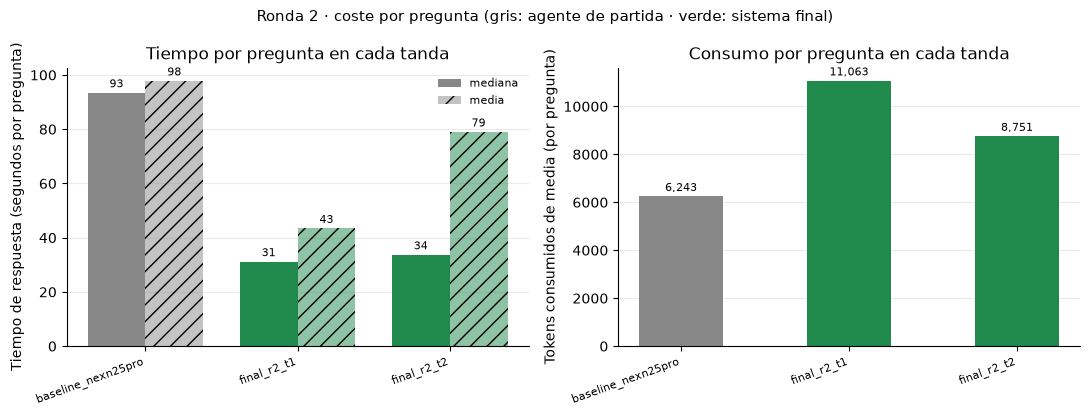

Latencia mediana entre tandas del sistema final: de 31 s a 34 s (mediana de medianas 32 s). Esa horquilla es del proveedor, no del agente.


In [15]:
if TANDAS_R2:
    etiquetas_lat = ([REFERENCIA_R2] if REFERENCIA_R2 else []) + TANDAS_R2
    colores_lat = [SISTEMA_COLOR['baseline'] if e == REFERENCIA_R2 else SISTEMA_COLOR['final']
                   for e in etiquetas_lat]
    mediana_lat = [(resumen_de(e) or {}).get('latencia_mediana_s') for e in etiquetas_lat]
    media_lat = [(resumen_de(e) or {}).get('latencia_media_s') for e in etiquetas_lat]
    tokens_lat = [(resumen_de(e) or {}).get('tokens_medios') for e in etiquetas_lat]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
    x = np.arange(len(etiquetas_lat))
    b1 = ax1.bar(x - 0.19, [v if v is not None else float('nan') for v in mediana_lat],
                 width=0.38, color=colores_lat, label='mediana')
    b2 = ax1.bar(x + 0.19, [v if v is not None else float('nan') for v in media_lat],
                 width=0.38, color=colores_lat, alpha=0.5, hatch='//', label='media')
    ax1.bar_label(b1, fmt=lambda v: f'{v:.0f}' if v == v else '', padding=2, fontsize=8)
    ax1.bar_label(b2, fmt=lambda v: f'{v:.0f}' if v == v else '', padding=2, fontsize=8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(etiquetas_lat, rotation=20, ha='right', fontsize=8)
    ax1.set_ylabel('Tiempo de respuesta (segundos por pregunta)')
    ax1.set_title('Tiempo por pregunta en cada tanda')
    ax1.legend(fontsize=8, frameon=False)

    b3 = ax2.bar(x, [v if v is not None else float('nan') for v in tokens_lat],
                 width=0.5, color=colores_lat)
    ax2.bar_label(b3, fmt=lambda v: f'{v:,.0f}' if v == v else '', padding=2, fontsize=8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(etiquetas_lat, rotation=20, ha='right', fontsize=8)
    ax2.set_ylabel('Tokens consumidos de media (por pregunta)')
    ax2.set_title('Consumo por pregunta en cada tanda')

    for ax in (ax1, ax2):
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.25)
        ax.set_axisbelow(True)
    fig.suptitle('Ronda 2 · coste por pregunta (gris: agente de partida · verde: sistema final)',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

    lat = [(resumen_de(t) or {}).get('latencia_mediana_s') for t in TANDAS_R2]
    lat = [v for v in lat if v is not None]
    if len(lat) > 1:
        print(f'Latencia mediana entre tandas del sistema final: de {min(lat):.0f} s a {max(lat):.0f} s '
              f'(mediana de medianas {statistics.median(lat):.0f} s). Esa horquilla es del proveedor, '
              f'no del agente.')
else:
    print('Sin tandas terminadas de la ronda 2.')


**Qué nos dice esto:** el código es idéntico en todas las tandas y aun así los aciertos por familia se mueven
de una a otra. Eso no es el agente cambiando de criterio: es el proveedor respondiendo distinto. El gráfico lo
hace visible de un vistazo: **donde la línea vertical es corta o no existe, el resultado es sólido; donde es
larga, la cifra depende de la tanda que te toque**. Por eso lo que se defiende en la memoria es la mediana con
su rango, nunca la mejor tanda suelta — y por eso el tiempo de respuesta se lee con la misma cautela.


## 8. Qué falta para cerrar la entrega

1. Terminar las tandas de la ronda 2 que sigan en curso y volver a ejecutar este cuaderno: las recoge solo.
2. Fijar en la memoria la **mediana con su rango**, nunca la mejor tanda suelta.
3. Regenerar la tabla comparativa oficial y actualizar `README.md` con esas cifras.
4. Repetir las pruebas, el escaneo de claves y el ensayo en un clon limpio del repositorio.

Mientras no estén esos pasos, toda tabla que mezcle modelos distintos lleva su aviso, y `candidato_07` se cita
siempre como **provisional, sin frenos de seguridad**.


## 9. Lista de comprobación

- [x] La medición histórica del agente de partida no se sobrescribe.
- [x] El agente mejorado conserva los nombres y las firmas de las cuatro herramientas.
- [x] El sistema final nunca se degrada en silencio al agente de partida.
- [x] El cuaderno se ejecuta entero sin internet con `EJECUTAR = False`.
- [x] Gráficos de aciertos por familia, tiempo y consumo, que incorporan solos las mediciones que aparezcan.
- [x] Las tandas repetidas de la ronda 2 se detectan solas y se resumen con mediana y rango.
- [ ] Ronda 2 terminada y cifras llevadas a la memoria.
- [ ] Clon limpio y presentación ensayados.
